In [3]:
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization (optional for notebooks)
shap.initjs()

In [4]:
import joblib

best_cat = joblib.load("../models/best_cat.pkl")

In [5]:
explainer = shap.TreeExplainer(best_cat)

In [5]:
import pandas as pd
X_train_smote = pd.read_csv("../data/processed/X_train_smote.csv")
y_train_smote = pd.read_csv("../data/processed/y_train_smote.csv").squeeze()
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [ ]:
shap_values = explainer(X_test)

In [1]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

NameError: name 'shap' is not defined

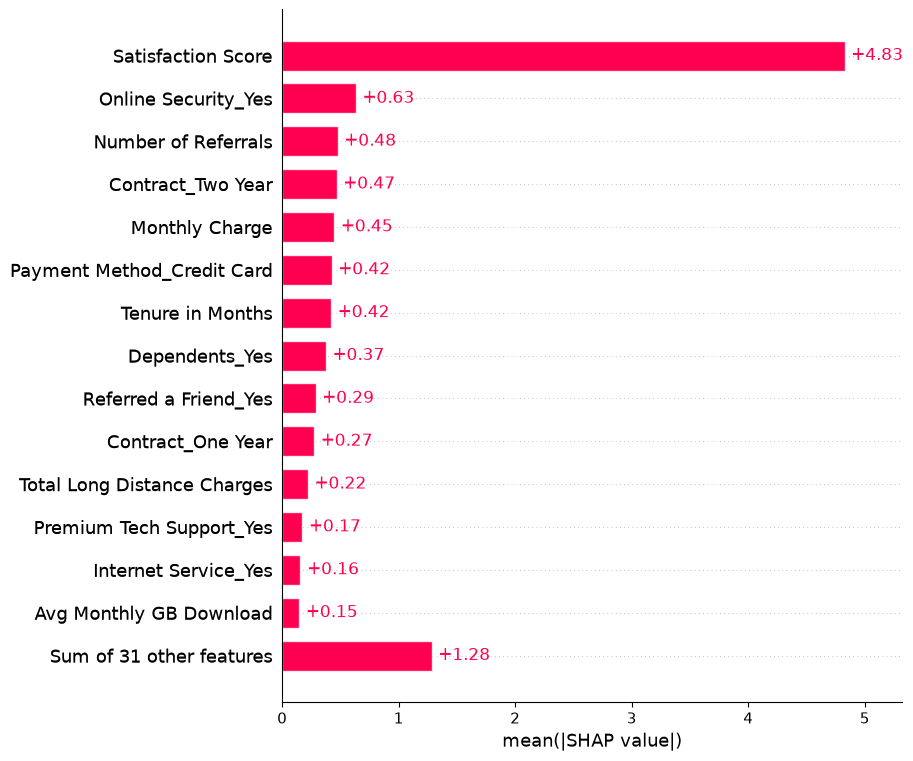

In [9]:
shap.plots.bar(
    shap_values,
    max_display=15
)

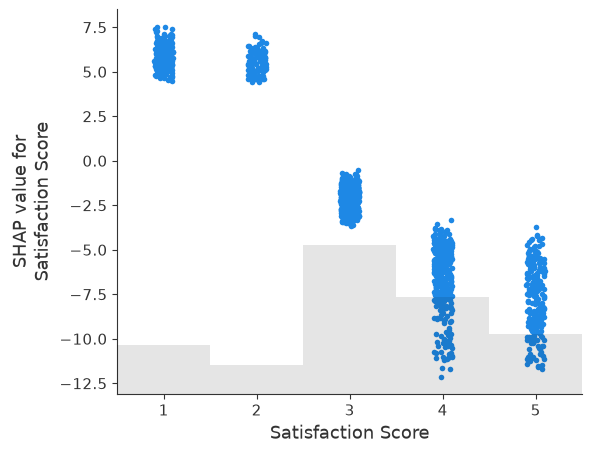

In [10]:
shap.plots.scatter(
    shap_values[:, "Satisfaction Score"],
)

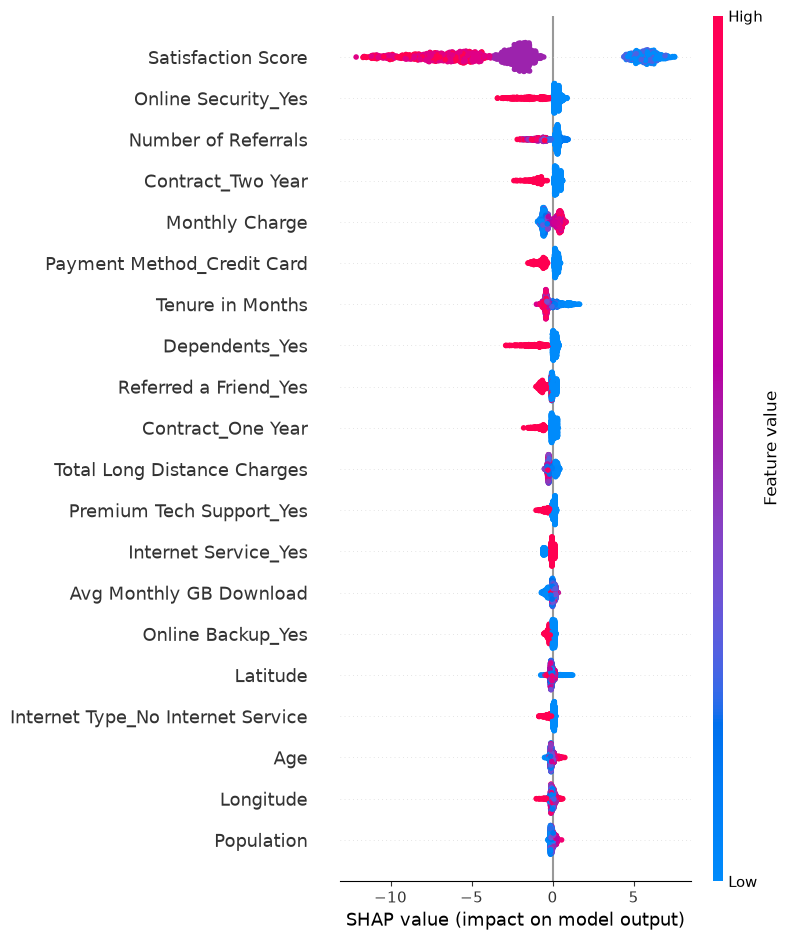

In [11]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig("../figures/global_shap_summary.png", dpi=300)
plt.show()

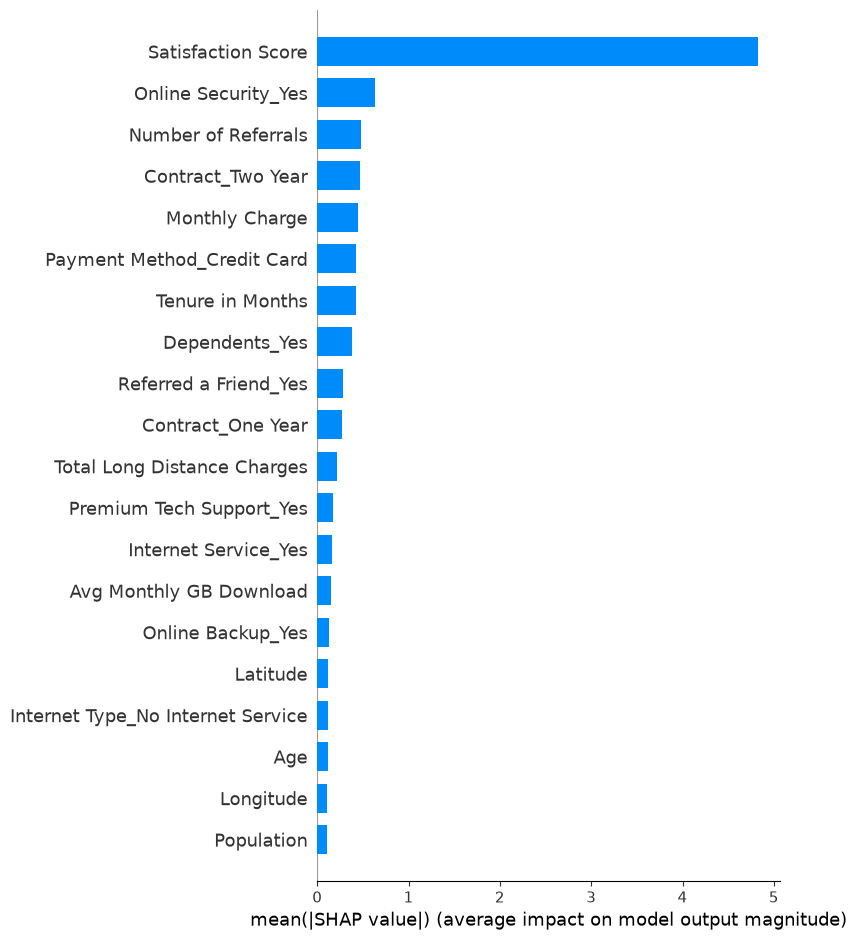

In [12]:
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../figures/global_shap_bar.png", dpi=300)
plt.show()

In [16]:
import joblib

voting_clf = joblib.load("../models/soft_voting.pkl")

In [17]:
import shap
import numpy as np

In [18]:
feature_names = X_train_smote.columns

def predict_fn(x):
    x = pd.DataFrame(x, columns=feature_names)
    return voting_clf.predict_proba(x)

background = shap.sample(X_train_smote, 100, random_state=42)

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

In [19]:
X_test_sample = X_test.sample(100, random_state=42)

In [20]:
shap_values = explainer.shap_values(
    X_test_sample,
    nsamples=200
)

  0%|          | 0/100 [00:00<?, ?it/s]

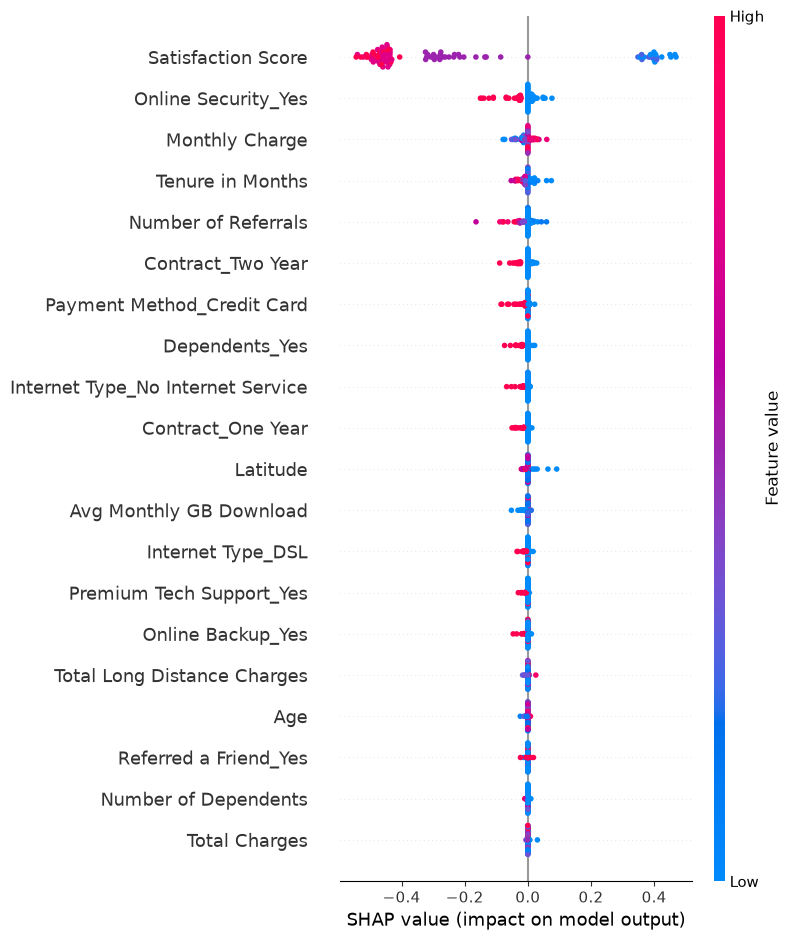

In [21]:
shap.summary_plot(
    shap_values[..., 1],
    X_test_sample
)

In [22]:
print(shap_values[0].shape)
print(shap_values[1].shape)
print(X_test_sample.shape)

(45, 2)
(45, 2)
(100, 45)


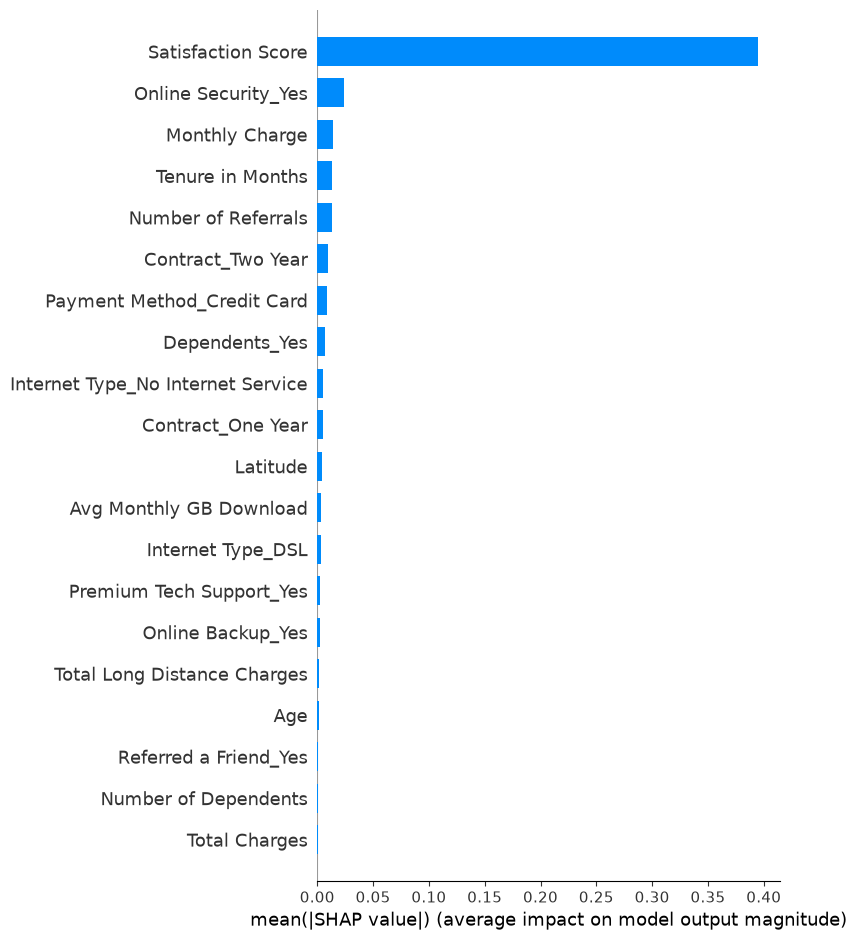

In [25]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    plot_type="bar"
)

In [24]:
print(shap.__version__)
print(type(shap_values))
print(np.array(shap_values).shape)

0.52.0
<class 'numpy.ndarray'>
(100, 45, 2)


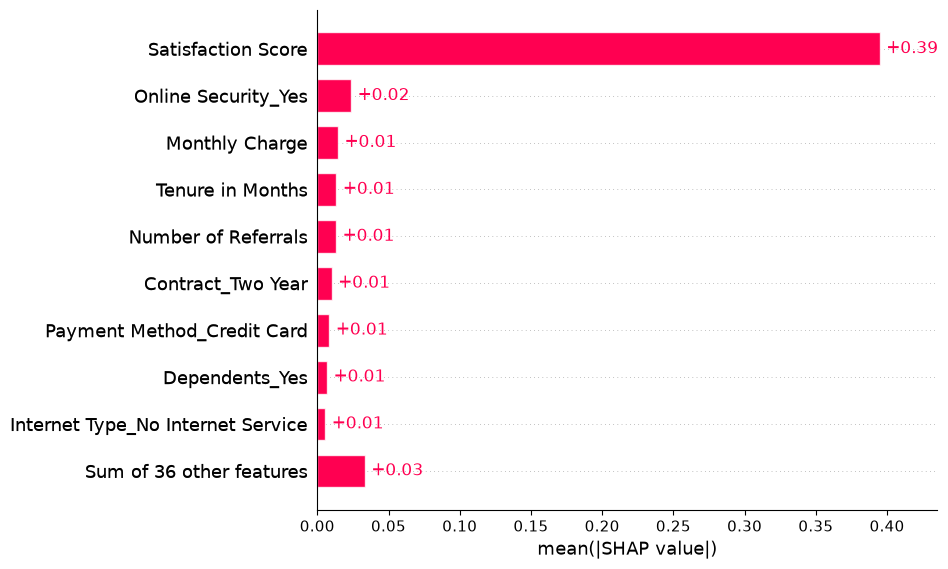

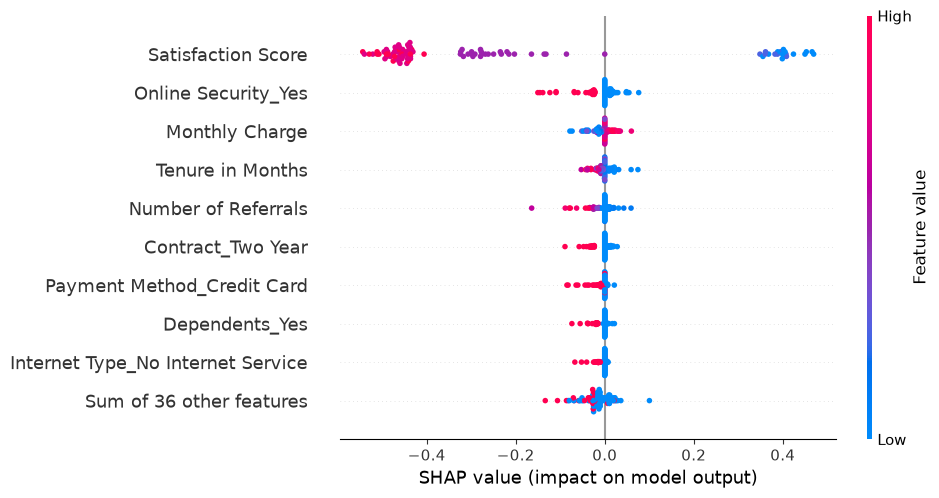

In [26]:
explanation = shap.Explanation(
    values=shap_values[:, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_sample.values,
    feature_names=X_test_sample.columns
)

shap.plots.bar(explanation)
shap.plots.beeswarm(explanation)

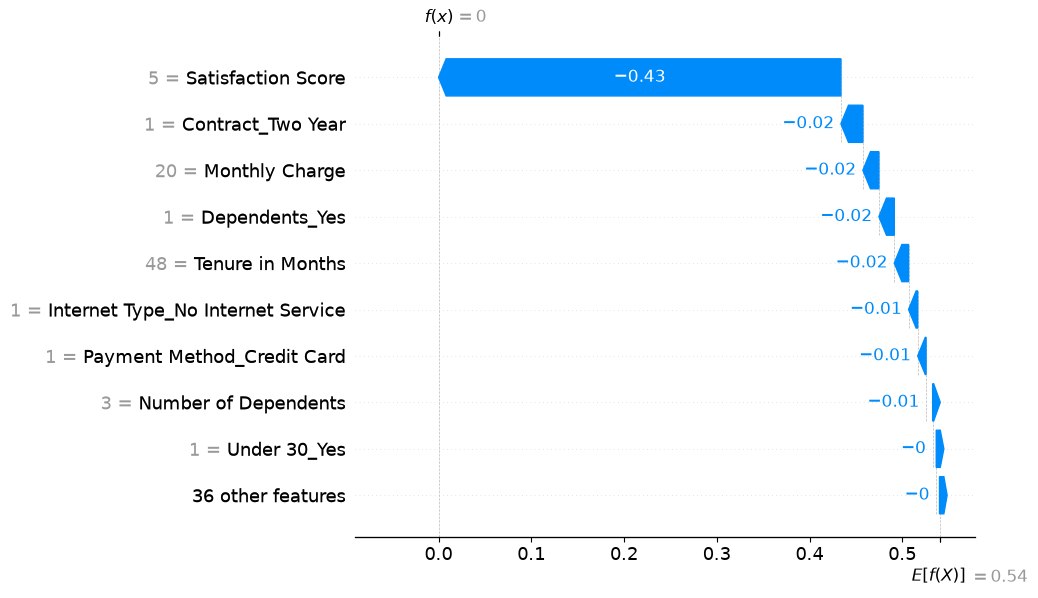

In [27]:
shap.plots.waterfall(explanation[0])

In [28]:
import joblib

kmeans = joblib.load("../models/kmeans.pkl")
scaler = joblib.load("../models/scaler.pkl")

In [31]:
df = pd.read_csv('../data/Preprocessed.csv')

In [32]:
X_cluster = df.drop(columns=["Churn Label"])

In [36]:
X_scaled = scaler.transform(X_cluster)
clusters = kmeans.predict(X_scaled)

X_cluster["Cluster"] = clusters

In [40]:
cluster0 =  X_cluster[X_cluster["Cluster"] == 0].drop(columns="Cluster")
cluster1 = X_cluster[X_cluster["Cluster"] == 1].drop(columns="Cluster") 

In [42]:
cluster0_sample = cluster0.sample(100, random_state=42)
cluster1_sample = cluster1.sample(100, random_state=42)

shap_cluster0 = explainer.shap_values(cluster0_sample, nsamples=200)
shap_cluster1 = explainer.shap_values(cluster1_sample, nsamples=200)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [43]:
import pandas as pd
import numpy as np

global_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Mean |SHAP|": np.abs(shap_values[:, :, 1]).mean(axis=0)
})

global_importance = global_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

global_importance.head(15)

,Feature,Mean |SHAP|
14,Satisfaction Score,0.394778
32,Online Security_Yes,0.023688
9,Monthly Charge,0.014472
6,Tenure in Months,0.013319
5,Number of Referrals,0.013115
41,Contract_Two Year,0.010004
43,Payment Method_Credit Card,0.008394
19,Dependents_Yes,0.006779
31,Internet Type_No Internet Service,0.005523
40,Contract_One Year,0.005180


In [44]:
cluster0_importance = pd.DataFrame({
    "Feature": cluster0.columns,
    "Mean |SHAP|": np.abs(shap_cluster0[:, :, 1]).mean(axis=0)
})

cluster0_importance = cluster0_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

cluster0_importance.head(15)

,Feature,Mean |SHAP|
14,Satisfaction Score,0.358716
32,Online Security_Yes,0.031475
6,Tenure in Months,0.018855
5,Number of Referrals,0.017019
41,Contract_Two Year,0.012766
9,Monthly Charge,0.012257
43,Payment Method_Credit Card,0.008146
40,Contract_One Year,0.007414
19,Dependents_Yes,0.005972
35,Premium Tech Support_Yes,0.004361


In [45]:
cluster1_importance = pd.DataFrame({
    "Feature": cluster1.columns,
    "Mean |SHAP|": np.abs(shap_cluster1[:, :, 1]).mean(axis=0)
})

cluster1_importance = cluster1_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

cluster1_importance.head(15)

,Feature,Mean |SHAP|
14,Satisfaction Score,0.400538
9,Monthly Charge,0.023673
31,Internet Type_No Internet Service,0.018822
41,Contract_Two Year,0.016317
5,Number of Referrals,0.013348
6,Tenure in Months,0.011832
43,Payment Method_Credit Card,0.010418
19,Dependents_Yes,0.010287
8,Avg Monthly GB Download,0.009277
40,Contract_One Year,0.004670


In [46]:
comparison = pd.DataFrame({
    "Global": global_importance["Feature"].head(10).values,
    "Cluster 0": cluster0_importance["Feature"].head(10).values,
    "Cluster 1": cluster1_importance["Feature"].head(10).values
})

comparison

,Global,Cluster 0,Cluster 1
0,Satisfaction Score,Satisfaction Score,Satisfaction Score
1,Online Security_Yes,Online Security_Yes,Monthly Charge
2,Monthly Charge,Tenure in Months,Internet Type_No Internet Service
3,Tenure in Months,Number of Referrals,Contract_Two Year
4,Number of Referrals,Contract_Two Year,Number of Referrals
5,Contract_Two Year,Monthly Charge,Tenure in Months
6,Payment Method_Credit Card,Payment Method_Credit Card,Payment Method_Credit Card
7,Dependents_Yes,Contract_One Year,Dependents_Yes
8,Internet Type_No Internet Service,Dependents_Yes,Avg Monthly GB Download
9,Contract_One Year,Premium Tech Support_Yes,Contract_One Year


In [47]:
global_importance.to_csv("../results/global_shap.csv", index=False)

cluster0_importance.to_csv("../results/cluster0_shap.csv", index=False)

cluster1_importance.to_csv("../results/cluster1_shap.csv", index=False)

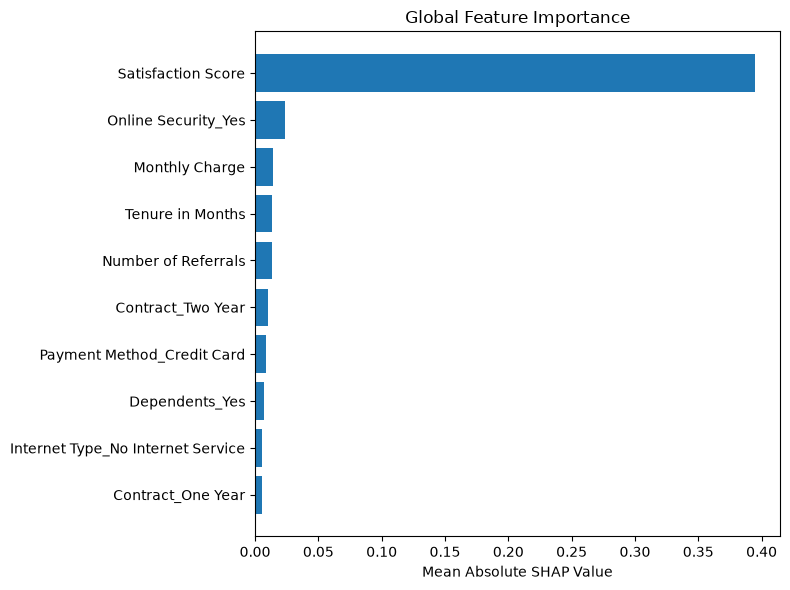

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    global_importance["Feature"][:10][::-1],
    global_importance["Mean |SHAP|"][:10][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.title("Global Feature Importance")

plt.tight_layout()
plt.show()

In [49]:
rank_global = global_importance.reset_index(drop=True)
rank_global["Global Rank"] = rank_global.index + 1

rank_cluster0 = cluster0_importance.reset_index(drop=True)
rank_cluster0["Cluster0 Rank"] = rank_cluster0.index + 1

rank_cluster1 = cluster1_importance.reset_index(drop=True)
rank_cluster1["Cluster1 Rank"] = rank_cluster1.index + 1

comparison_rank = (
    rank_global[["Feature","Global Rank"]]
    .merge(rank_cluster0[["Feature","Cluster0 Rank"]], on="Feature")
    .merge(rank_cluster1[["Feature","Cluster1 Rank"]], on="Feature")
)

comparison_rank

,Feature,Global Rank,Cluster0 Rank,Cluster1 Rank
0,Satisfaction Score,1,1,1
1,Online Security_Yes,2,2,11
2,Monthly Charge,3,6,2
3,Tenure in Months,4,3,6
4,Number of Referrals,5,4,5
5,Contract_Two Year,6,5,4
6,Payment Method_Credit Card,7,7,7
7,Dependents_Yes,8,9,8
8,Internet Type_No Internet Service,9,31,3
9,Contract_One Year,10,8,10


In [50]:
comparison_rank["Rank Difference"] = (
    comparison_rank["Cluster0 Rank"] -
    comparison_rank["Cluster1 Rank"]
).abs()

comparison_rank.sort_values(
    "Rank Difference",
    ascending=False
).head(15)

,Feature,Global Rank,Cluster0 Rank,Cluster1 Rank,Rank Difference
13,Premium Tech Support_Yes,14,10,45,35
8,Internet Type_No Internet Service,9,31,3,28
12,Internet Type_DSL,13,11,34,23
28,Offer_Offer D,29,41,20,21
43,Offer_Offer A,44,45,24,21
14,Online Backup_Yes,15,14,30,16
27,Internet Service_Yes,28,35,22,13
44,Streaming Music_Yes,45,29,40,11
36,Senior Citizen_Yes,37,43,32,11
41,Payment Method_Mailed Check,42,27,38,11


In [51]:
corr = np.corrcoef(
    global_importance["Mean |SHAP|"],
    cluster0_importance["Mean |SHAP|"]
)[0,1]

print(corr)

0.9994225013135648


In [52]:
corr = np.corrcoef(
    global_importance["Mean |SHAP|"],
    cluster1_importance["Mean |SHAP|"]
)[0,1]

print(corr)

0.9997996111878475


In [53]:
corr = np.corrcoef(
    cluster1_importance["Mean |SHAP|"],
    cluster0_importance["Mean |SHAP|"]
)[0,1]

print(corr)

0.9994937673174072
